In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pickle
%matplotlib inline


path = "../data/headless_bugtrap_mppi/bugtrap_seed_0.pkl"

# path = "../data/headless_bugtrap_mppi/bugtrap_seed_6.pkl"

# path = "../data/headless_bugtrap_cem/bugtrap_seed_0.pkl"
path = "../data/test/test_seed_1.pkl"


path = "../../data/headless_bugtrap_anmtp/test_seed_0.pkl"

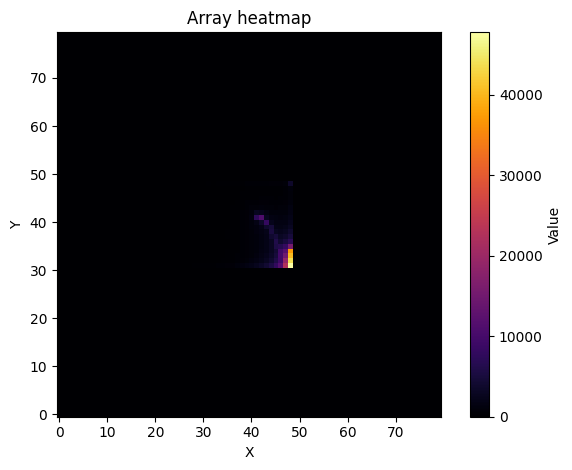

In [2]:
with open(path, "rb") as f:
    obj = pickle.load(f)

# If the pickle stores the array directly:
arr = np.asarray(obj).T

if arr.ndim > 2:
    arr = arr.sum(axis=tuple(range(arr.ndim - 2)))
    
# softmax normalization (optional) with temperature and max subtraction for stability
# temperature = 5000
# arr_max = np.max(arr)
# arr_exp = np.exp((arr - arr_max) / temperature)
# arr = arr_exp / np.sum(arr_exp)

    

# --- Plot heatmap ---
plt.imshow(arr, origin="lower", cmap="inferno", interpolation="nearest")
plt.colorbar(label="Value")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Array heatmap")
plt.tight_layout()
plt.show()

# (Optional) Save figure:
# plt.savefig("heatmap.png", dpi=200)

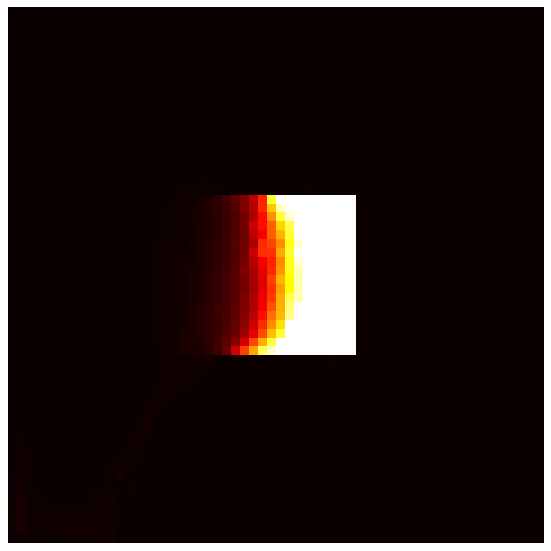

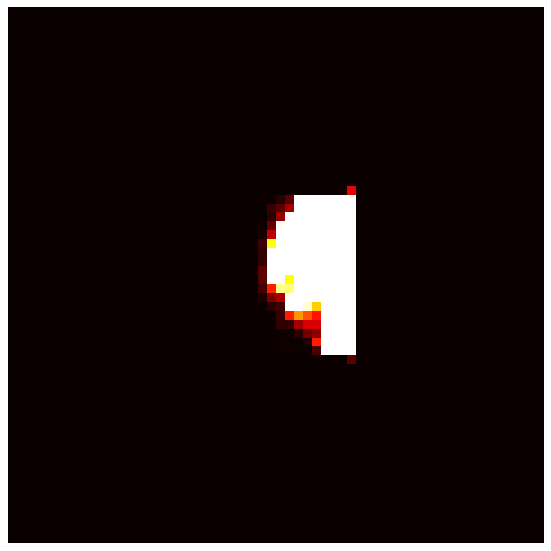

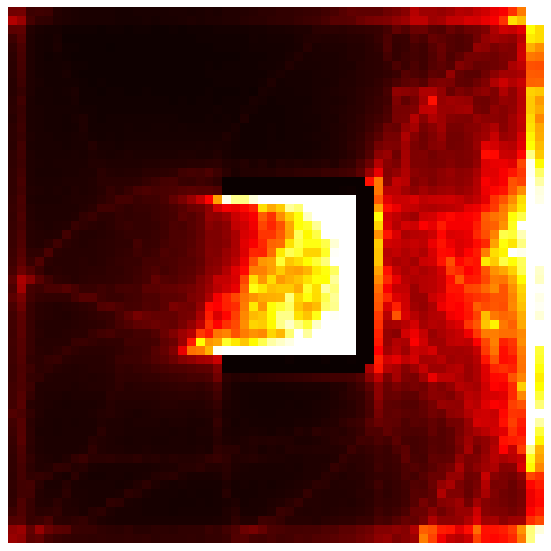

In [18]:

#
for algo in ["mppi", "cem", "mtp"]:
    arr_sum = None
    for i in [0,1,2,3,4]:
        path = f"../data/headless_bugtrap_{algo}/bugtrap_seed_{i}.pkl"
        with open(path, "rb") as f:
            obj = pickle.load(f)

        arr = np.asarray(obj).T

        if arr.ndim > 2:
            arr = arr.sum(axis=tuple(range(arr.ndim - 2)))

        if arr_sum is None:
            arr_sum = arr.copy()
        else:
            arr_sum += arr   # accumulate

    # Normalize to [0,1] for qualitative heatmap
    # arr_norm = (arr_sum - arr_sum.min()) / (arr_sum.max() - arr_sum.min())


    # arr_sum = arr_sum.clip(min=0, max=250000)
    arr_sum = np.clip(arr_sum, 1, np.percentile(arr_sum, 98))
    
    
    
    # cut off outer rows and coluimns for better visualization
    cutoff = 10
    arr_sum = arr_sum[cutoff:-cutoff, cutoff:-cutoff]

    # --- Create figure ---
    fig, ax = plt.subplots(figsize=(7, 7), dpi=80)

    # Heatmap (qualitative, no axis values)
    im = ax.imshow(
        arr_sum,
        origin="lower",
        cmap="hot",
        # norm=LogNorm(),
        interpolation="none",
    )

    # Remove ticks, labels, spines (clean look)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


    # Tight layout
    plt.tight_layout()

    # Save high-quality
    plt.savefig(f"heatmap_fancy_{algo}.png", dpi=600, bbox_inches="tight")

    plt.show()

    # print values in 5 largest bins
    # flat_indices = np.argsort(arr_sum, axis=None)[-5:]
    # indices = np.unravel_index(flat_indices, arr_sum.shape)
    # print("Top 5 bins (indices and values):")
    # for idx in zip(indices[0], indices[1]):
    #     print(f"Index: {idx}, Value: {arr_sum[idx]}")